# Prog 3

        ┌───┐          ┌───┐           ░ ┌─┐         
   q_0: ┤ H ├───────■──┤ H ├───────────░─┤M├─────────
        ├───┤       │  └───┘┌───┐      ░ └╥┘┌─┐      
   q_1: ┤ H ├───────┼────■──┤ H ├──────░──╫─┤M├──────
        ├───┤       │    │  └───┘┌───┐ ░  ║ └╥┘┌─┐   
   q_2: ┤ H ├───────┼────┼────■──┤ H ├─░──╫──╫─┤M├───
        ├───┤┌───┐┌─┴─┐┌─┴─┐┌─┴─┐└───┘ ░  ║  ║ └╥┘┌─┐
   q_3: ┤ X ├┤ H ├┤ X ├┤ X ├┤ X ├──────░──╫──╫──╫─┤M├
        └───┘└───┘└───┘└───┘└───┘      ░  ║  ║  ║ └╥┘
meas: 4/══════════════════════════════════╩══╩══╩══╩═
                                          0  1  2  3 


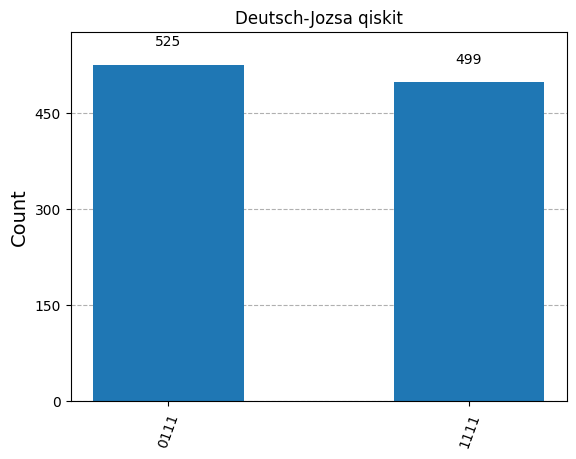

In [1]:
import qiskit as qk
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

qc = qk.QuantumCircuit(4)
qc.x(3)
for i in range(4):
    qc.h(i)

for i in range(3):
    qc.cx(i, 3)

for i in range(3):
    qc.h(i)

qc.measure_all()
print(qc)

sim = AerSimulator()
result = sim.run(qc).result()
counts = result.get_counts(qc)
plot_histogram(counts, title="Deutsch-Jozsa qiskit")

$f(x_1 x_2 x_3) = x_1 \oplus x_2 \oplus x_3$ is a balanced function. Deutsch-Jozsa outputs all 1s (excluding the last wire which is a minus that we throw away) which is correct since 0 is constant and 1 is balanced.

{'1111': 501, '1110': 523}
     ┌───┐          ┌───┐     ┌─┐           
q_0: ┤ H ├───────■──┤ H ├─────┤M├───────────
     ├───┤       │  └───┘┌───┐└╥┘     ┌─┐   
q_1: ┤ H ├───────┼────■──┤ H ├─╫──────┤M├───
     ├───┤       │    │  └───┘ ║ ┌───┐└╥┘┌─┐
q_2: ┤ H ├───────┼────┼────■───╫─┤ H ├─╫─┤M├
     ├───┤┌───┐┌─┴─┐┌─┴─┐┌─┴─┐ ║ └┬─┬┘ ║ └╥┘
q_3: ┤ X ├┤ H ├┤ X ├┤ X ├┤ X ├─╫──┤M├──╫──╫─
     └───┘└───┘└───┘└───┘└───┘ ║  └╥┘  ║  ║ 
c: 4/══════════════════════════╩═══╩═══╩══╩═
                               0   3   1  2 


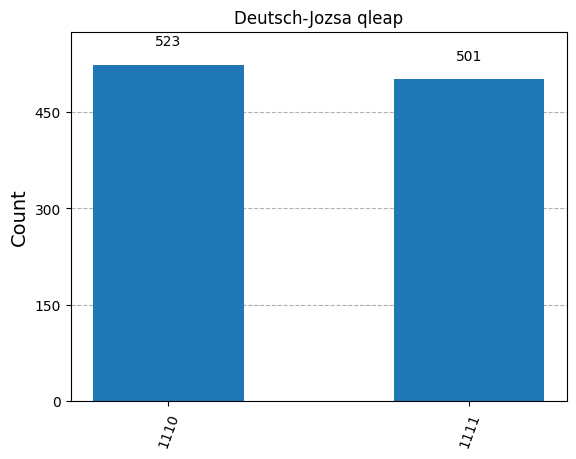

In [2]:
import qleap as ql

ql.Circuit.clear()
qs = ql.QState(4)
ql.X(qs[3])

for i in range(4):
    ql.Hadamard(qs[i])

for i in range(3):
    ql.Cnot(qs[i], qs[3])

for i in range(3):
    ql.Hadamard(qs[i])

ql.Measurement(qs)

result = ql.Circuit.run()
print(result.counts)
ql.Circuit.draw()
plot_histogram(result.counts, title="Deutsch-Jozsa qleap")